In [1]:
import pandas as pd


In [3]:
df=pd.read_excel("Retail_sales_Revenue.xlsx")

In [4]:
print(df.head())


   Transactio_ ID Order_Date Customer_ID  Gender  Age Product_Category  \
0               1 2023-11-24     CUST001    Male   34           Beauty   
1               2 2023-02-27     CUST002  Female   26         Clothing   
2               3 2023-01-13     CUST003    Male   50      Electronics   
3               4 2023-05-21     CUST004    Male   37         Clothing   
4               5 2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price_per_Unit  Total_Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  


In [5]:
df.isnull().sum()

Transactio_ ID      0
Order_Date          0
Customer_ID         0
Gender              0
Age                 0
Product_Category    0
Quantity            0
Price_per_Unit      0
Total_Amount        0
dtype: int64

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.fillna(0,inplace=True)

In [12]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

In [13]:
# Rename columns for consistency
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transactio__id    1000 non-null   int64         
 1   order_date        1000 non-null   datetime64[ns]
 2   customer_id       1000 non-null   object        
 3   gender            1000 non-null   object        
 4   age               1000 non-null   int64         
 5   product_category  1000 non-null   object        
 6   quantity          1000 non-null   int64         
 7   price_per_unit    1000 non-null   int64         
 8   total_amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 78.1+ KB


In [18]:
# Total Revenue
total_revenue = df["total_amount"].sum()

In [19]:
# Top 5 Categories by Sales
top_categories = df.groupby("product_category")["total_amount"].sum().nlargest(5)

In [20]:
# Monthly Revenue Trend
df["month"] = df["order_date"].dt.strftime("%Y-%m")  # Extract year-month
monthly_revenue = df.groupby("month")["total_amount"].sum()

In [21]:
# Sales by Gender
sales_by_gender = df.groupby("gender")["total_amount"].sum()

In [22]:
print("Total Revenue:", total_revenue)
print("Top Categories:\n", top_categories)
print("Monthly Revenue Trend:\n", monthly_revenue)
print("Sales by Gender:\n", sales_by_gender)

Total Revenue: 456000
Top Categories:
 product_category
Electronics    156905
Clothing       155580
Beauty         143515
Name: total_amount, dtype: int64
Monthly Revenue Trend:
 month
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Name: total_amount, dtype: int64
Sales by Gender:
 gender
Female    232840
Male      223160
Name: total_amount, dtype: int64


In [23]:
pivot_monthly_revenue = df.pivot_table(index="month", values="total_amount", aggfunc="sum")
pivot_top_category = df.pivot_table(index="product_category", values="total_amount", aggfunc="sum").nlargest(5, "total_amount")
pivot_sales_gender = df.pivot_table(index="gender", values="total_amount", aggfunc="sum")

In [24]:
pivot_monthly_revenue


,total_amount
month,
2023-01,35450
2023-02,44060
2023-03,28990
2023-04,33870
2023-05,53150
2023-06,36715
2023-07,35465
2023-08,36960
2023-09,23620


In [25]:
print(pivot_top_category)


                  total_amount
product_category              
Electronics             156905
Clothing                155580
Beauty                  143515


In [27]:
pivot_sales_gender

,total_amount
gender,
Female,232840
Male,223160


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

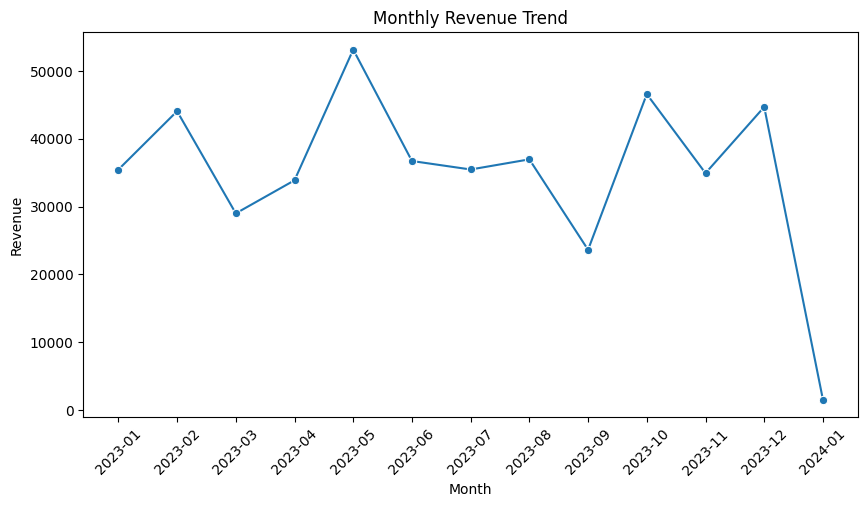

In [29]:
# Monthly Revenue Trend
plt.figure(figsize=(10, 5))
sns.lineplot(x=monthly_revenue.index, y=monthly_revenue.values, marker="o")
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()


C:\Users\priyakoter\AppData\Local\Temp\ipykernel_21776\1903734004.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette="viridis")


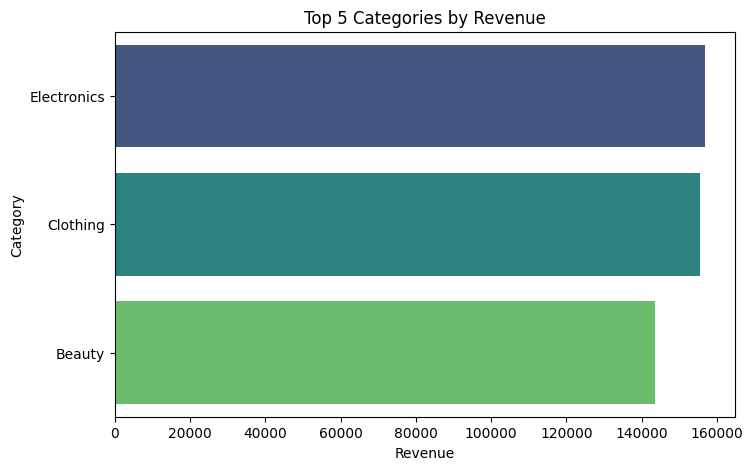

In [30]:
# Top 5 Categories
plt.figure(figsize=(8, 5))
sns.barplot(x=top_categories.values, y=top_categories.index, palette="viridis")
plt.title("Top 5 Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Category")
plt.show()

In [35]:
pip install xlsxwriter

   ---------------------------------------- 0.0/165.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/165.1 kB ? eta -:--:--
   ---------------------------------- ----- 143.4/165.1 kB 4.2 MB/s eta 0:00:01
   ---------------------------------------- 165.1/165.1 kB 3.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


DEPRECATION: Loading egg at c:\users\priyakoter\appdata\local\programs\python\python311\lib\site-packages\dlib-19.24.99-py3.11-win-amd64.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330

[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:
import xlsxwriter

output_file = "Retail_Sales_Dashboard.xlsx"
workbook = xlsxwriter.Workbook(output_file)
worksheet = workbook.add_worksheet("Dashboard")

# Add KPI values
worksheet.write("A1", "Total Revenue")
worksheet.write("B1", total_revenue)

# Insert pivot data
worksheet.write_column("A3", ["Month"] + list(pivot_monthly_revenue.index))
worksheet.write_column("B3", ["Revenue"] + list(pivot_monthly_revenue["total_amount"]))

# Insert a chart
chart = workbook.add_chart({"type": "line"})
chart.add_series({
    "categories": "=Dashboard!$A$4:$A$15",
    "values": "=Dashboard!$B$4:$B$15",
    "name": "Monthly Revenue",
})
worksheet.insert_chart("D3", chart)

workbook.close()
print(f"Dashboard saved: {output_file}")


Dashboard saved: Retail_Sales_Dashboard.xlsx
